# 23 &middot; Fast Complementary Dynamics: secondary motion that never fights the rig

An animator poses a character with a **rig**. *Complementary dynamics* (Zhang et al. 2020) adds physical
secondary motion (jiggle, sag, follow-through) on top of it, splitting every displacement into a rig part and a
complementary part, $u = u_r + u_c$, under one rule: the physics may never make a motion the rig can already make.
We build a full-order solver to watch that rule at work, then the real-time version of *Fast Complementary
Dynamics via Skinning Eigenmodes* (Benchekroun et al., SIGGRAPH 2023).

$$\boxed{\,J^{\top} M D\,u_c = 0\,}$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils

# Accelerate BLAS raises spurious floating-point flags inside some matmuls; every value stays finite.
np.seterr(divide="ignore", over="ignore", invalid="ignore")

NOTEBOOK = "023_fast_complementary_dynamics"                       # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK) # results/023_fast_complementary_dynamics/
MEDIA_DIR = "media"                                                # tracked copies for the website
# beam (a metronome arm)
BEAM_NX, BEAM_NY = 40, 5          # vertices along the beam's length / across its width
THICKNESS = 0.1                   # width / length of the strip (then normalized to height 2)
# material and time stepping
MATERIAL = "arap"                 # simkit elastic material
YM, PR = 1e5, 0.0                 # Young's modulus, Poisson ratio (ARAP only uses mu)
RHO = 1e3                         # density
DT = 1e-2                         # timestep
NSTEPS = 200                      # simulated steps
BCD_ITERS = 10                    # local/global iterations per step
# rig: the animator sweeps the handle's x-translation
AMP, PERIOD = 3.0, 80             # sweep amplitude, period in steps
# momentum-leak field
LEAK_DT = 1.0                     # diffusion time that spreads the boundary seed inward
# fast complementary dynamics
K_MODES = 10                      # rig-orthogonal skinning eigenmodes (each gives (dim+1)*dim columns of B)
N_CLUSTERS = 20                   # rotation clusters
CONSTRAINT_RTOL = 1e-10           # relative singular-value cutoff for independent weight-space constraint rows
# validation
VALID_STEP = 20                   # step at which derivatives and BCD convergence are checked
VALID_ITERS = 30                  # BCD iterations for the convergence plot
FD_H = 1e-6                       # central-difference step
NEWTON_ITERS, NEWTON_TOL = 30, 1e-10   # Newton iterations / step tolerance for the reduced reference solve
# timing sweep
SWEEP_RES = [(40, 5), (70, 7), (100, 8), (140, 9), (180, 10)]   # (BEAM_NX, BEAM_NY) per mesh
BENCH_WARMUP, BENCH_STEPS = 2, 12                                # untimed + timed steps per solver and mesh
# video
FPS = 30                          # frame rate (one frame per step)
BITRATE = 1200                    # mp4 bitrate in kbps
MODE_SCALE = 0.3                  # largest vertex displacement when drawing the columns of J
RIG_C, FULL_C, RED_C = "#d62728", "#1f77b4", "#2ca02c"          # rig / full / reduced colors

## 1 &middot; The rig: one global handle

`beam_mesh` builds the metronome arm: libigl's unit-square grid, squeezed into a thin strip, stood upright and
normalized to height 2 (`simkit.normalize_and_center`).

In [2]:
def beam_mesh(nx, ny):
    """Thin upright beam with nx vertices along its length and ny across, centered, height 2."""
    V, T = igl.triangulated_grid(nx, ny)
    X = np.column_stack([-THICKNESS * V[:, 1], V[:, 0]])
    X = simkit.normalize_and_center(X)
    return X, T

X, T = beam_mesh(BEAM_NX, BEAM_NY)
n, dim = X.shape
print(f"beam: {n} vertices, {len(T)} triangles")

beam: 200 vertices, 312 triangles


The simplest rig is a **single affine handle**: one LBS bone with weight 1 everywhere. `simkit.lbs_jacobian`
builds its Jacobian $J$, the rig pose is $x = J\,p$ with 6 parameters $p$ (in 2D), and the columns of $J$ span
every affine motion: the **control space**. `p0` reproduces the rest shape, and `handle_pose` is the animator,
sweeping the handle's $x$-translation $p_{-2}$ back and forth.

In [3]:
def affine_rig(X):
    """One global affine LBS handle: its Jacobian J (x = J p) and the pose p0 with J p0 = X."""
    J = simkit.lbs_jacobian(X, np.ones((len(X), 1)))
    p0 = simkit.project_into_subspace(X.reshape(-1, 1), J)
    return J, p0

def handle_pose(p0, i):
    """The animator's input at step i: the rest pose with a sinusoidal x-translation."""
    p = p0.copy()
    p[-2] = AMP * np.sin(2 * np.pi * i / PERIOD)
    return p

J, p0 = affine_rig(X)
print(f"rig: J is {J.shape} -> {J.shape[1]} DOFs,  p0 = {np.round(p0.ravel(), 6)}")

rig: J is (400, 6) -> 6 DOFs,  p0 = [ 1.  0.  0.  1.  0. -0.]


Left: the beam at rest and its handle (orange, at the translation origin). Right: each column of $J$ applied
to the beam over its gray rest shape. Any displacement in their span belongs to the animator.

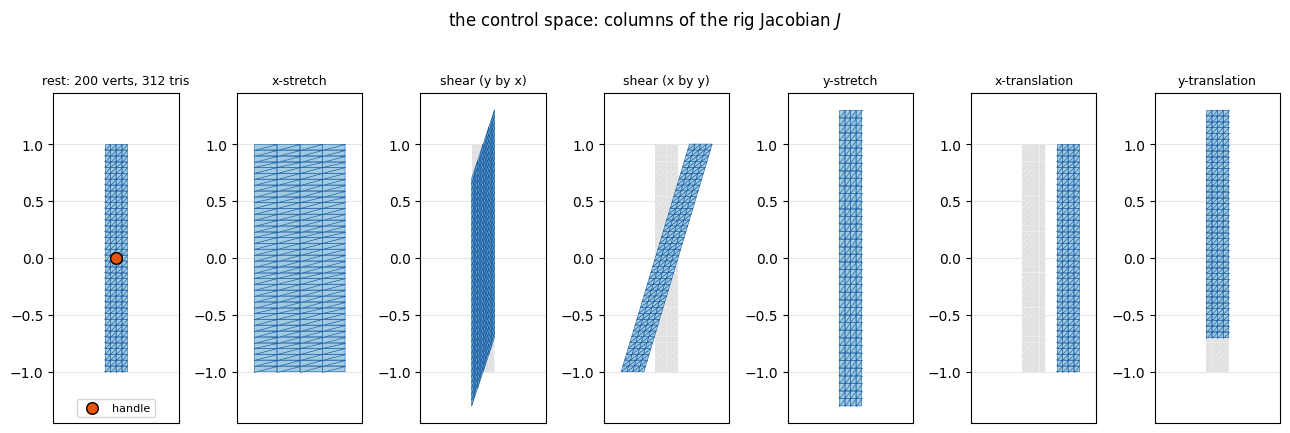

In [4]:
col_names = ["x-stretch", "shear (y by x)", "shear (x by y)", "y-stretch", "x-translation", "y-translation"]
col_shapes = [X + MODE_SCALE * J[:, c].reshape(n, dim) / np.abs(J[:, c]).max() for c in range(J.shape[1])]
lims = utils.auto_limits([X] + col_shapes, pad=0.15)
fig, axes = plt.subplots(1, 7, figsize=(13, 4.8))
utils.plot_mesh(axes[0], X, T, title=f"rest: {n} verts, {len(T)} tris", lims=lims, lw=0.4)
axes[0].scatter(*p0[-2:].ravel(), s=70, color=utils.HANDLE_C, edgecolors="k", zorder=6, label="handle")
axes[0].legend(loc="lower center", fontsize=8)
for ax, shape, name in zip(axes[1:], col_shapes, col_names):
    utils.PolyMeshArtist(ax, X, T, facecolor="0.88", edgecolor="none", zorder=1)
    utils.plot_mesh(ax, shape, T, title=name, lims=lims, lw=0.4)
for ax in axes:
    ax.title.set_fontsize(9)
    ax.set_xticks([])
fig.suptitle("the control space: columns of the rig Jacobian $J$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rig_modes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_rig_modes.png"))
plt.show()

The animator's input on its own: the handle (orange) sweeps left and right and the beam follows rigidly.
There is no physics yet.

In [5]:
rig_states = [(J @ handle_pose(p0, i)).reshape(n, dim) for i in range(NSTEPS)]
handle_traj = [handle_pose(p0, i)[-2:].ravel() for i in range(NSTEPS)]
fig, anim = utils.animate_colored_mesh_panels(
    [dict(states=rig_states, T=T, title="rig pose  $x = J\\,p$", color=RIG_C, handle=handle_traj)],
    fps=FPS, suptitle="The animator's input: a rigid beam swept left and right")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "rig.mp4"), fps=FPS, bitrate=BITRATE,
                                         copy_to=os.path.join(MEDIA_DIR, "023_rig.mp4"))
plt.close(fig)
utils.embed_video(video)

## 2 &middot; Full-order complementary dynamics

Each timestep is a backward-Euler step: minimize inertia plus ARAP elasticity over the total position
$x = J\,p_{\text{next}} + u_c$, with inertial target $\tilde x = 2x_{\text{curr}} - x_{\text{prev}}$. The only
thing that makes it *complementary* rather than ordinary elastodynamics is one linear constraint:

$$\min_{u_c}\ \tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2 + E_{\text{ARAP}}(x)
  \qquad\text{s.t.}\qquad J^{\top} M D\,u_c = 0 .$$

`cd_operators` precomputes everything constant: the mass matrix $M$ (orthogonality is measured in momentum),
the deformation Jacobian $G$ (positions to per-triangle $F$), the ARAP Laplacian $L = G^\top W G$ with
$W = \mu\,\text{vol}$, the rig, and the **momentum-leak field** $d$ ($D = \operatorname{diag}(d)$): diffuse 1
inward from the boundary and take one minus that. Where $d = 0$ momentum leaks, so tissue rides along with the
rig; where $d = 1$ it is conserved and resists. The constraint is $A = J^\top M D$, and the constant KKT matrix
of the constrained global step (below) is factored once, here.

In [6]:
def cd_operators(X, T):
    """Constant operators of full-order complementary dynamics on the mesh (X, T)."""
    n, dim = X.shape
    M = sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.eye(dim)).tocsc()
    G = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu_s, lam_s = simkit.ympr_to_lame(YM, PR)
    mu = np.full((len(T), 1), mu_s)
    lam = np.full((len(T), 1), lam_s)
    W_arap = sp.sparse.kron(sp.sparse.diags((mu * vol).ravel()), sp.sparse.eye(dim * dim))
    L = (G.T @ W_arap @ G).tocsc()                                   # ARAP Laplacian (rotations frozen)
    J, p0 = affine_rig(X)
    bnd = np.unique(simkit.boundary_edges(T))
    leak = simkit.diffuse_field(X, T, bnd, np.ones((len(bnd), 1)), dt=LEAK_DT, normalize=True)
    d = 1.0 - leak
    D = sp.sparse.kron(sp.sparse.diags(d.ravel()), sp.sparse.eye(dim))
    A = J.T @ M @ D                                                  # rig-orthogonality constraint
    H_elastic = L                                                    # global-step matrix H = L + M / h^2
    H_inertia = M / DT**2
    H = (H_elastic + H_inertia).tocsc()
    A_sp = sp.sparse.csc_matrix(A)
    kkt_solve = sp.sparse.linalg.factorized(sp.sparse.bmat([[H, A_sp.T], [A_sp, None]]).tocsc())
    return dict(n=n, dim=dim, M=M, G=G, vol=vol, mu=mu, lam=lam, W_arap=W_arap, L=L,
                J=J, p0=p0, d=d, A=A, H=H, kkt_solve=kkt_solve)

ops = cd_operators(X, T)
print(f"constraint A = J^T M D: {ops['A'].shape},  KKT system: {ops['H'].shape[0] + ops['A'].shape[0]} unknowns")

constraint A = J^T M D: (6, 400),  KKT system: 406 unknowns


The leak weight $d$ is 0 on the whole surface of the thin beam (the diffusion seeds) and rises to 1 along its
core, so the beam's interior carries the momentum that will produce secondary motion.

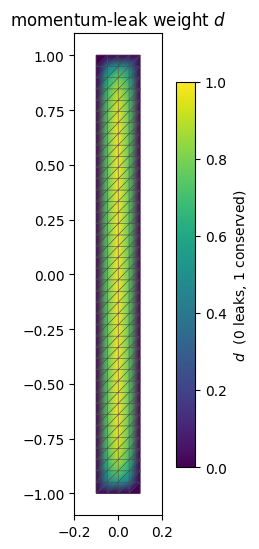

In [7]:
fig, ax = plt.subplots(figsize=(3.4, 5.6))
utils.plot_scalar_field(ax, X, T, ops["d"], title="momentum-leak weight $d$", label="$d$  (0 leaks, 1 conserved)")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "leak_field.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_leak_field.png"))
plt.show()

`full_cd_system` is one step's objective in the complementary displacement $u_c$. Its energy, gradient and
Hessian are inertia plus ARAP from `simkit.energies` (used below to validate the solver). The solver is **block
coordinate descent** (tutorials 21 and 22), so the system also returns its two steps: the **local step** fits the
closest rotation to each triangle's $F$ (`polar_svd`), and the **global step** freezes them and solves the
quadratic together with the constraint, the prefactored KKT system
$\begin{bmatrix} H & A^{\top}\\ A & 0\end{bmatrix}$ with $H = L + M/h^2$.

In [8]:
def full_cd_system(ops, u_curr, u_prev, p_curr, p_prev, p_next):
    """Backward-Euler step of full-order complementary dynamics, in the complementary displacement u."""
    n, dim, M, G, J, H = ops["n"], ops["dim"], ops["M"], ops["G"], ops["J"], ops["H"]
    mu, lam, vol, W_arap, kkt_solve = ops["mu"], ops["lam"], ops["vol"], ops["W_arap"], ops["kkt_solve"]
    n_con = ops["A"].shape[0]
    x_curr = J @ p_curr + u_curr
    x_prev = J @ p_prev + u_prev
    x_tilde = simkit.energies.be_target(x_curr, x_prev, DT)          # inertial target 2 x_curr - x_prev
    Jp = J @ p_next                                                  # the rig's pose this step

    def energy_func(u):
        x = Jp + u
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT)
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL)
        E_total = E_inertia + E_elastic
        return E_total

    def gradient_func(u):
        x = Jp + u
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT)
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL)
        g_total = g_inertia + g_elastic
        return g_total

    def hessian_func(u):
        x = Jp + u
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT)
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL, psd=True)
        H_total = H_inertia + H_elastic
        return H_total

    def local_step(u):
        F = (G @ (Jp + u)).reshape(-1, dim, dim)
        R = simkit.polar_svd(F)[0]                                   # closest rotation, per triangle
        return R.reshape(-1, 1)

    def global_step(u, R):
        f_inertia = M @ x_tilde / DT**2
        f_elastic = G.T @ (W_arap @ R)
        f_rig = -H @ Jp
        f_total = f_inertia + f_elastic + f_rig
        return kkt_solve(np.vstack([f_total, np.zeros((n_con, 1))]))[: len(u)]

    return energy_func, gradient_func, hessian_func, local_step, global_step

`rollout` plays the animator's sweep through either system: each step builds the system at the current state,
runs `simkit.solvers.block_coord` for `BCD_ITERS` local/global iterations, and records the pose $J\,p + u_c$,
the rig-orthogonality residual $\lVert J^{\top} M D\,u_c\rVert$ and the step's wall-clock time. For the reduced
solver of section 3 the state is $z$, lifted by its basis as $u_c = B\,z$.

In [9]:
def rollout(system_func, ops, nsteps=NSTEPS):
    """Simulate the handle sweep; returns per-step poses, solver states, rig poses, residuals, seconds."""
    J, p0, A, dim = ops["J"], ops["p0"], ops["A"], ops["dim"]
    B = ops.get("B")                                                 # None for the full-order system
    s_curr = np.zeros((J.shape[0] if B is None else B.shape[1], 1))
    s_prev = s_curr.copy()
    p_curr, p_prev = p0.copy(), p0.copy()
    out = dict(states=[], s=[], p=[], residual=[], seconds=[])
    for i in range(nsteps):
        p_next = handle_pose(p0, i)
        t0 = time.perf_counter()
        _, _, _, local_step, global_step = system_func(ops, s_curr, s_prev, p_curr, p_prev, p_next)
        s_next = simkit.solvers.block_coord(s_curr, global_step, local_step, tolerance=0.0, max_iter=BCD_ITERS)
        out["seconds"].append(time.perf_counter() - t0)
        s_prev, s_curr = s_curr, s_next
        p_prev, p_curr = p_curr, p_next
        u_c = s_curr if B is None else B @ s_curr                    # complementary displacement
        out["states"].append((J @ p_curr + u_c).reshape(-1, dim))
        out["s"].append(s_curr)
        out["p"].append(p_curr)
        out["residual"].append(np.linalg.norm(A @ u_c))
    return out

Run the full-order solver under the sweep. The KKT solve holds the constraint to round-off at every step.

In [10]:
full = rollout(full_cd_system, ops)
t_full = 1000 * np.mean(full["seconds"])
print(f"full-order: {t_full:.1f} ms/step, {len(T)} rotations/step, {J.shape[0]} DOFs")
print(f"max rig-orthogonality residual  ||J^T M D u_c|| = {max(full['residual']):.1e}")

full-order: 5.8 ms/step, 312 rotations/step, 400 DOFs
max rig-orthogonality residual  ||J^T M D u_c|| = 1.0e-13


Top: the rig alone. Bottom: the same rig **plus** the complementary physics, over the rig pose in gray. The beam
whips and trails as the handle reverses: secondary motion the animator never authored, and by construction none
of it is a motion the handle could have made itself.

In [11]:
fig, anim = utils.animate_colored_mesh_panels([
    dict(states=rig_states, T=T, title="rig only  $J\\,p$", color=RIG_C, handle=handle_traj),
    dict(states=full["states"], T=T, title="rig + complementary  $J\\,p + u_c$", color=FULL_C,
         ghost=rig_states, handle=handle_traj),
], ncols=1, fps=FPS, suptitle="Full-order complementary dynamics")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "full.mp4"), fps=FPS, bitrate=BITRATE,
                                         copy_to=os.path.join(MEDIA_DIR, "023_full.mp4"))
plt.close(fig)
utils.embed_video(video)

## 3 &middot; Fast complementary dynamics

The full step has two mesh-sized costs: a `polar_svd` for **every triangle** in each local step, and a sparse
KKT solve over **every vertex** in each global step. Refine the mesh and both grow. *Fast* complementary
dynamics removes both with two ideas.

* **Rig-orthogonal skinning eigenmodes.** Restrict $u_c = B\,z$ to skinning eigenmodes (tutorial 17) computed
  *subject to* $J^\top M D\,B = 0$. The constraint then holds for any $z$, and the global step is a tiny,
  unconstrained dense solve.
* **Rotation clustering.** Triangles that move alike share **one rotation per cluster** in the local step.

`fast_cd_operators` precomputes both ideas. $B$ = `lbs_jacobian(X, W)` is linear in the weight fields $W$, so
$J^\top M D\,B = 0$ is a linear constraint on each field $w$; we assemble its rows with one `einsum` and pass an
SVD basis of them to `skinning_eigenmodes(..., Aeq=...)`. (`simkit.lbs_weight_space_constraint` builds the same
rows, but its redundant-row removal keeps the *first* rows rather than an independent set, which for this rig
drops constraints.) `spectral_cubature` then clusters the triangles, and `cluster_grouping_matrices` gives the
cluster sums $P$: the local step fits each cluster's rotation to its $\mu\,\text{vol}$-weighted sum of $F$.

In [12]:
def fast_cd_operators(X, T, ops):
    """Rig-orthogonal subspace B, rotation clusters and reduced matrices, added to the full operators."""
    n, dim, M, G, J, L, A = ops["n"], ops["dim"], ops["M"], ops["G"], ops["J"], ops["L"], ops["A"]
    # Idea 1: J^T M D B = 0 for B = lbs(W)  <=>  sum_v A[c, v, i] [X_v, 1]_j w[v] = 0 for every weight field w
    X1 = np.hstack([X, np.ones((n, 1))])
    C_w = np.einsum("cvi,vj->cijv", A.reshape(-1, n, dim), X1).reshape(-1, n)
    _, s_w, Vt_w = np.linalg.svd(C_w, full_matrices=False)
    Aeq = Vt_w[s_w > CONSTRAINT_RTOL * s_w[0]]                       # independent weight-space rows
    W, _, B = simkit.skinning_eigenmodes(X, T, K_MODES, Aeq=Aeq)
    B = simkit.orthonormalize(B, M=M)
    # Idea 2: cluster triangles; each cluster shares one rotation, fit to its (mu vol)-weighted sum of F
    _, _, labels = simkit.spectral_cubature(X, T, W, N_CLUSTERS, return_labels=True)
    labels = np.asarray(labels).ravel()
    P, _ = simkit.cluster_grouping_matrices(labels, X, T)
    P_w = sp.sparse.kron(P @ sp.sparse.diags((ops["mu"] * ops["vol"]).ravel()), sp.sparse.eye(dim * dim))
    GB = P_w @ G @ B                                                 # z -> clustered F sums
    GJ = P_w @ G @ J                                                 # p -> clustered F sums
    # reduced global-step matrices, factored once
    BMB = B.T @ M @ B
    BMJ = B.T @ M @ J
    BLJ = B.T @ L @ J
    H_red_elastic = B.T @ L @ B
    H_red_inertia = BMB / DT**2
    H_red = H_red_elastic + H_red_inertia
    chol = sp.linalg.cho_factor(H_red)
    return dict(ops, Aeq=Aeq, W=W, B=B, labels=labels, n_clusters=P.shape[0],
                GB=GB, GJ=GJ, BMB=BMB, BMJ=BMJ, BLJ=BLJ, chol=chol)

red_ops = fast_cd_operators(X, T, ops)
print(f"weight-space constraint: {red_ops['Aeq'].shape},  subspace B: {red_ops['B'].shape}")
print(f"structural rig-orthogonality  ||(J^T M D) B|| = {np.linalg.norm(ops['A'] @ red_ops['B']):.1e}")

weight-space constraint: (6, 200),  subspace B: (400, 60)
structural rig-orthogonality  ||(J^T M D) B|| = 2.2e-12


The printout confirms 6 independent constraint rows and a 60-column $B$ that is rig-orthogonal to round-off. Below,
its weight fields $w_k$ (red and blue are opposite signs; each field spawns 6 columns of $B$) and the rotation
clusters, one color per shared rotation: 20 clusters capture the whole beam's bending, so the local step's cost
no longer depends on how finely it is meshed.

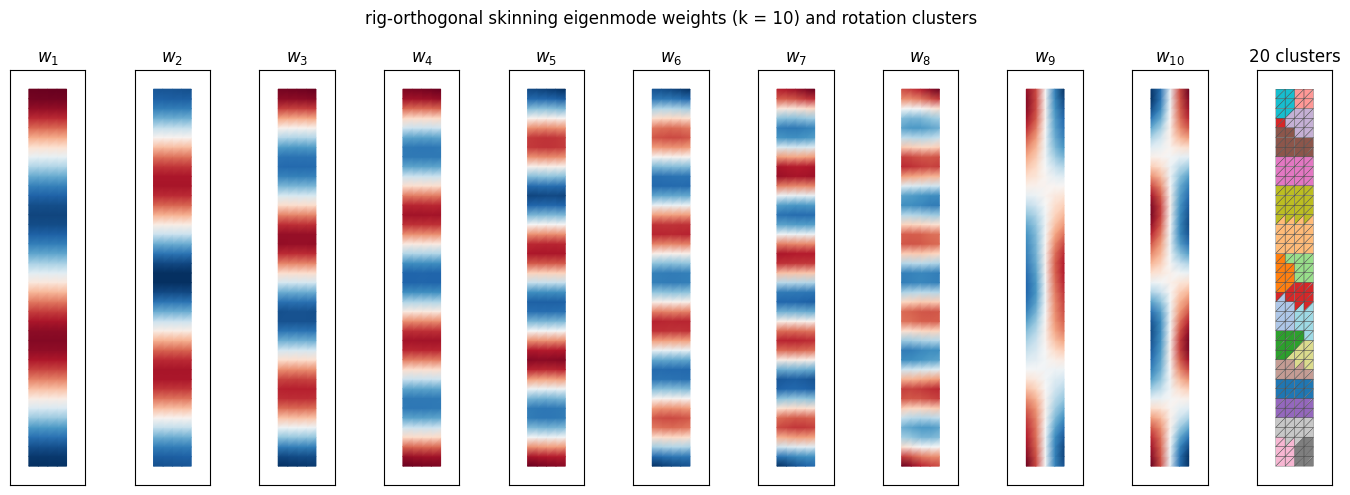

In [13]:
fig, axes = plt.subplots(1, K_MODES + 1, figsize=(14, 5.0))
for k, ax in enumerate(axes[:-1]):
    w = red_ops["W"][:, k]
    vmax = np.abs(w).max()
    utils.plot_scalar_field(ax, X, T, w, title=f"$w_{{{k + 1}}}$", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                            edges=False, colorbar=False)
utils.plot_scalar_field(axes[-1], X, T, red_ops["labels"], title=f"{red_ops['n_clusters']} clusters",
                        cmap="tab20", edges=True, colorbar=False)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"rig-orthogonal skinning eigenmode weights (k = {K_MODES}) and rotation clusters")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "subspace.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_subspace.png"))
plt.show()

`fast_cd_system` mirrors `full_cd_system` in subspace coordinates $z$. Its energy, gradient and Hessian are the
same inertia plus ARAP at $x = J\,p_{\text{next}} + B\,z$, pulled back by $B^\top$ (per-triangle rotations, the
reference the clustered solver approximates). The local step is one `polar_svd` per cluster, and the global step
solves the dense reduced system $(B^\top L B + B^\top M B/h^2)\,z = f$ with the prefactored Cholesky factor.

In [14]:
def fast_cd_system(ops, z_curr, z_prev, p_curr, p_prev, p_next):
    """Backward-Euler step of fast complementary dynamics, in the rig-orthogonal subspace coordinates z."""
    n, dim, M, G, J, B = ops["n"], ops["dim"], ops["M"], ops["G"], ops["J"], ops["B"]
    mu, lam, vol = ops["mu"], ops["lam"], ops["vol"]
    GB, GJ, BMB, BMJ, BLJ, chol = ops["GB"], ops["GJ"], ops["BMB"], ops["BMJ"], ops["BLJ"], ops["chol"]
    x_curr = J @ p_curr + B @ z_curr
    x_prev = J @ p_prev + B @ z_prev
    z_tilde = simkit.energies.be_target(z_curr, z_prev, DT)          # inertial targets in z and p
    p_tilde = simkit.energies.be_target(p_curr, p_prev, DT)
    Jp = J @ p_next

    def energy_func(z):
        x = Jp + B @ z
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT)
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL)
        E_total = E_inertia + E_elastic
        return E_total

    def gradient_func(z):
        x = Jp + B @ z
        g_inertia = B.T @ simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT)
        g_elastic = B.T @ simkit.energies.elastic_gradient_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL)
        g_total = g_inertia + g_elastic
        return g_total

    def hessian_func(z):
        x = Jp + B @ z
        H_inertia = B.T @ (simkit.energies.kinetic_hessian_be(M, DT) @ B)
        H_elastic = B.T @ (simkit.energies.elastic_hessian_x(x.reshape(n, dim), G, mu, lam, vol, MATERIAL,
                                                             psd=True) @ B)
        H_total = H_inertia + H_elastic
        return H_total

    def local_step(z):
        F_c = (GB @ z + GJ @ p_next).reshape(-1, dim, dim)
        R_c = simkit.polar_svd(F_c)[0]                               # one rotation per cluster
        return R_c.reshape(-1, 1)

    def global_step(z, R_c):
        f_inertia = BMB @ z_tilde / DT**2
        f_rig_inertia = -BMJ @ (p_next - p_tilde) / DT**2
        f_elastic = GB.T @ R_c
        f_rig_elastic = -BLJ @ p_next
        f_total = f_inertia + f_rig_inertia + f_elastic + f_rig_elastic
        return sp.linalg.cho_solve(chol, f_total)

    return energy_func, gradient_func, hessian_func, local_step, global_step

Run the fast solver under the same sweep. It is several times faster already on this small mesh, and keeps the
residual at round-off without any constraint solve.

In [15]:
red = rollout(fast_cd_system, red_ops)
t_red = 1000 * np.mean(red["seconds"])
print(f"reduced: {t_red:.2f} ms/step, {red_ops['n_clusters']} rotations/step, {red_ops['B'].shape[1]} DOFs"
      f"   ->   {t_full / t_red:.1f}x faster than full-order")
print(f"max rig-orthogonality residual  ||J^T M D B z|| = {max(red['residual']):.1e}")

reduced: 0.73 ms/step, 20 rotations/step, 60 DOFs   ->   8.0x faster than full-order
max rig-orthogonality residual  ||J^T M D B z|| = 3.7e-13


## 4 &middot; Validating both solvers

Three cheap checks at step `VALID_STEP`: each system's gradient against central differences (`simkit.gradient_cfd`),
the energy per local/global iteration, and the rig-orthogonality residual over the whole run. For the reduced
system, Newton on the same subspace energy with per-triangle rotations (its `hessian_func`) gives the minimum that
rotation clustering trades away.

full-order      gradient vs central differences: relative error 3.3e-10
fast (reduced)  gradient vs central differences: relative error 1.0e-09
fast (reduced)  energy after 10 clustered BCD iterations 1486.93  vs  Newton with per-triangle rotations 1478.48  (+0.6%)


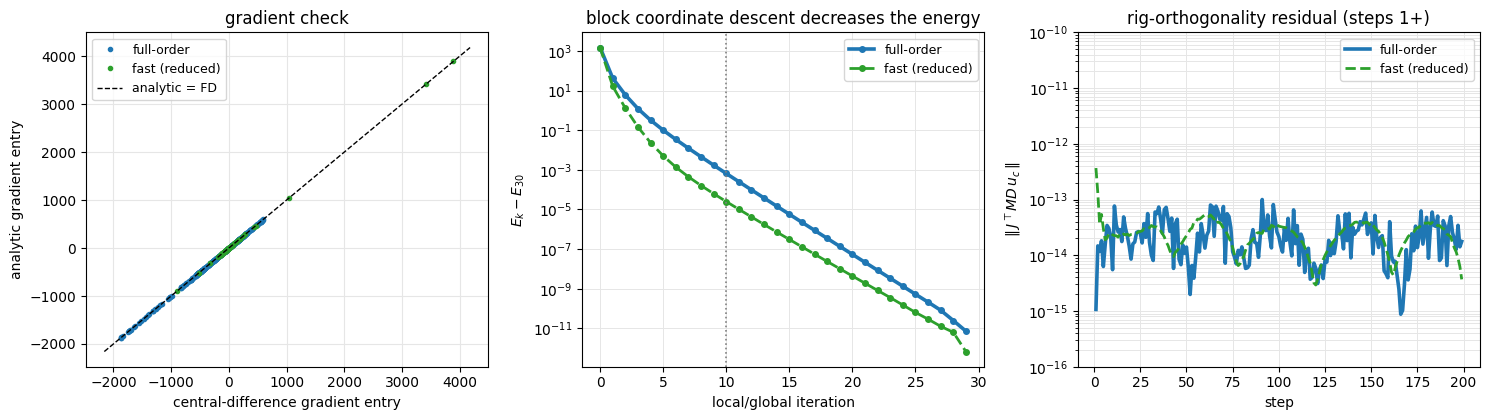

In [16]:
i = VALID_STEP
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
curves = {}
for name, system_func, sys_ops, run, color in [("full-order", full_cd_system, ops, full, FULL_C),
                                                ("fast (reduced)", fast_cd_system, red_ops, red, RED_C)]:
    energy_func, gradient_func, hessian_func, local_step, global_step = system_func(
        sys_ops, run["s"][i], run["s"][i - 1], run["p"][i], run["p"][i - 1], handle_pose(p0, i + 1))
    s0 = run["s"][i]
    g = gradient_func(s0).ravel()
    g_fd = simkit.gradient_cfd(lambda s: np.array(energy_func(s.reshape(-1, 1))), s0.ravel().copy(), FD_H)
    print(f"{name:15s} gradient vs central differences: relative error {np.linalg.norm(g_fd - g) / np.linalg.norm(g):.1e}")
    axes[0].plot(g_fd, g, "o", ms=3, color=color, label=name)
    s, energies = s0.copy(), [energy_func(s0)]
    for _ in range(VALID_ITERS):
        s = global_step(s, local_step(s))
        energies.append(energy_func(s))
    curves[name] = np.array(energies) - energies[-1]
    if system_func is fast_cd_system:
        s_newton = simkit.solvers.newton_solver(s0.copy(), energy_func, gradient_func, hessian_func,
                                                max_iter=NEWTON_ITERS, tolerance=NEWTON_TOL)
        E_bcd, E_newton = energies[BCD_ITERS], energy_func(s_newton)
        print(f"{name:15s} energy after {BCD_ITERS} clustered BCD iterations {E_bcd:.2f}  vs  Newton with per-triangle "
              f"rotations {E_newton:.2f}  (+{100 * (E_bcd - E_newton) / E_newton:.1f}%)")
lo, hi = axes[0].get_xlim()
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="analytic = FD")
axes[0].set_xlabel("central-difference gradient entry")
axes[0].set_ylabel("analytic gradient entry")
axes[0].set_title("gradient check")
axes[0].legend(fontsize=9)
axes[0].grid(True, color="0.9")
utils.residual_plot(curves, ax=axes[1], colors={"full-order": FULL_C, "fast (reduced)": RED_C}, markers=True,
                    xlabel="local/global iteration", ylabel="$E_k - E_{%d}$" % VALID_ITERS,
                    title="block coordinate descent decreases the energy")
axes[1].axvline(BCD_ITERS, color="0.5", ls=":", lw=1.2)
utils.residual_plot({"full-order": full["residual"][1:], "fast (reduced)": red["residual"][1:]},
                    np.arange(1, NSTEPS), ax=axes[2], colors={"full-order": FULL_C, "fast (reduced)": RED_C},
                    ylim=(1e-16, 1e-10), xlabel="step", ylabel="$\\|\\,J^\\top M D\\,u_c\\,\\|$",
                    title="rig-orthogonality residual (steps 1+)")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "validation.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_validation.png"))
plt.show()

The analytic gradients sit on the diagonal. Both solvers decrease the energy at every local/global iteration
(dotted line: the `BCD_ITERS` used per step), and the residual stays at round-off throughout: enforced by the
KKT solve in the full model, structural in the reduced one. Clustering is cheap in accuracy too: the clustered
solve ends only 0.6% above the per-triangle-rotation minimum of the same subspace.

## 5 &middot; Rig vs. full vs. reduced

The reduced solve reproduces the full-order secondary motion (the same whip and trail) while solving a 60-DOF
dense system with 20 rotations instead of a 406-unknown KKT system with 312.

In [17]:
fig, anim = utils.animate_colored_mesh_panels([
    dict(states=rig_states, T=T, title="rig", color=RIG_C, handle=handle_traj),
    dict(states=full["states"], T=T, title=f"full  ({len(T)} rotations, {J.shape[0]} DOFs)", color=FULL_C,
         ghost=rig_states, handle=handle_traj),
    dict(states=red["states"], T=T, title=f"reduced  ({red_ops['n_clusters']} rotations, {red_ops['B'].shape[1]} DOFs)",
         color=RED_C, ghost=rig_states, handle=handle_traj),
], ncols=1, fps=FPS, suptitle="Complementary dynamics: full-order vs. fast (skinning eigenmodes)")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "compare.mp4"), fps=FPS, bitrate=BITRATE,
                                         copy_to=os.path.join(MEDIA_DIR, "023_compare.mp4"))
plt.close(fig)
utils.embed_video(video)

Quantitatively: the horizontal lag of the beam's top vertex behind the rig, and the complementary displacement
magnitude $\lVert u_c\rVert$ at the step of largest lag (dotted), on the deformed beams with one shared color
scale. The reduced tip swings in phase with the full one at a somewhat smaller amplitude: 60 DOFs and 20 shared
rotations make the beam a little stiffer, but the displacement pattern (largest at the tips) is the same.

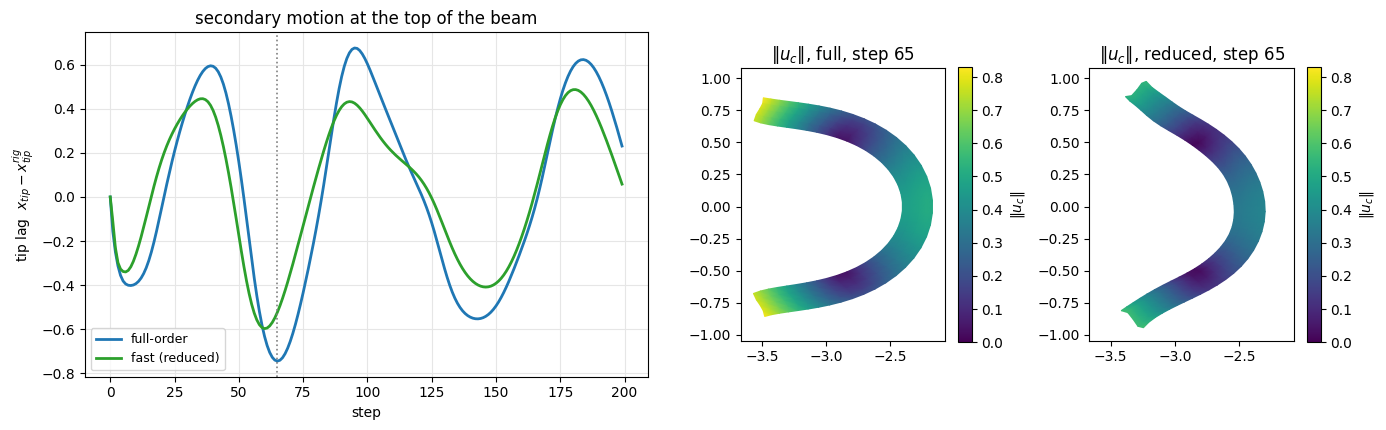

In [18]:
tip = np.argmin(np.linalg.norm(X - np.array([0.0, X[:, 1].max()]), axis=1))
lag = {name: np.array([s[tip, 0] - r[tip, 0] for s, r in zip(run["states"], rig_states)])
       for name, run in [("full-order", full), ("fast (reduced)", red)]}
i_max = int(np.argmax(np.abs(lag["full-order"])))
uc_mag = {name: np.linalg.norm(run["states"][i_max] - rig_states[i_max], axis=1) for name, run in [("full", full), ("reduced", red)]}
vmax = max(v.max() for v in uc_mag.values())
lims = utils.auto_limits([full["states"][i_max], red["states"][i_max]], pad=0.1)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
utils.line_plot(np.arange(NSTEPS), lag, colors={"full-order": FULL_C, "fast (reduced)": RED_C}, ax=axes[0],
                xlabel="step", ylabel="tip lag  $x_{tip} - x_{tip}^{rig}$", title="secondary motion at the top of the beam")
axes[0].axvline(i_max, color="0.5", ls=":", lw=1.2)
for ax, (name, run) in zip(axes[1:], [("full", full), ("reduced", red)]):
    utils.plot_scalar_field(ax, run["states"][i_max], T, uc_mag[name], title=f"$\\|u_c\\|$, {name}, step {i_max}",
                            vmin=0, vmax=vmax, lims=lims, edges=False, label="$\\|u_c\\|$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "secondary_motion.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_secondary_motion.png"))
plt.show()

## 6 &middot; Timing: how the gap grows with resolution

The reduced cost is set by the subspace size and the cluster count, **both fixed** as the mesh is refined, while
the full-order cost grows with it. We sweep these beam meshes (bottom row: the top of each beam, zoomed), all
with the same rig, leak-field construction and subspace sizes.

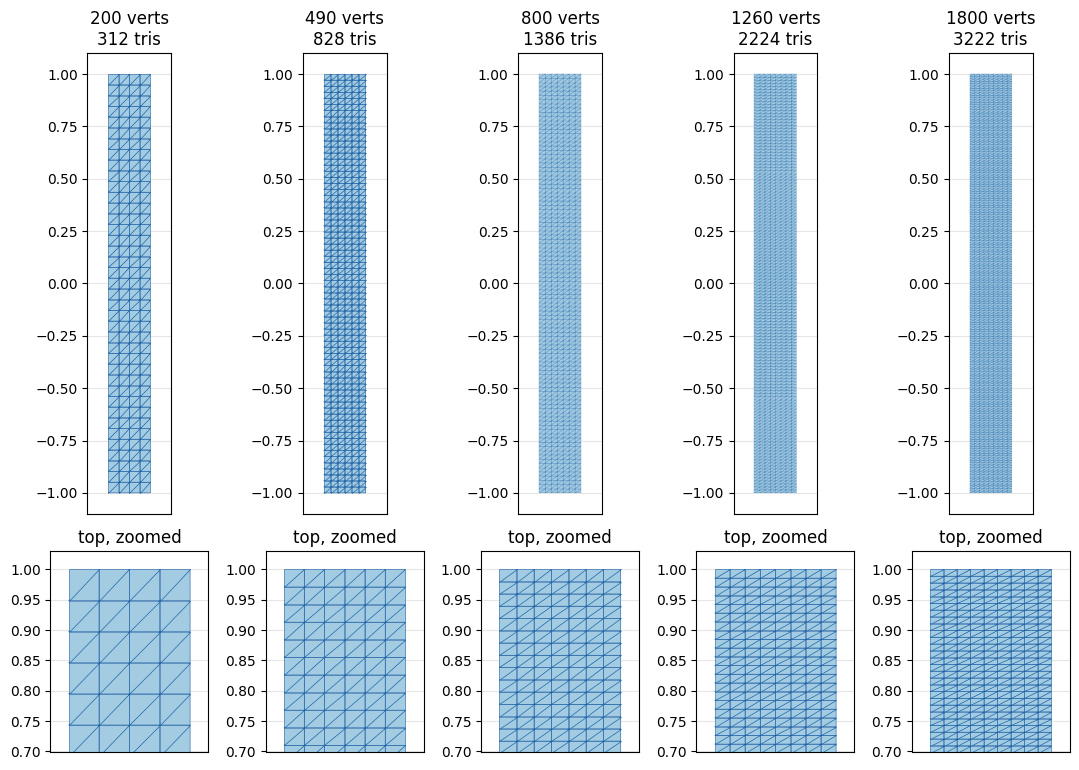

In [19]:
sweep_meshes = [beam_mesh(nx, ny) for nx, ny in SWEEP_RES]
fig, axes = plt.subplots(2, len(sweep_meshes), figsize=(11, 7.8), gridspec_kw={"height_ratios": [2.3, 1]})
for (ax, ax_zoom), (Xs, Ts) in zip(axes.T, sweep_meshes):
    utils.plot_mesh(ax, Xs, Ts, title=f"{len(Xs)} verts\n{len(Ts)} tris", lw=0.15 if len(Xs) > 500 else 0.4)
    utils.plot_mesh(ax_zoom, Xs, Ts, title="top, zoomed", lims=((-0.13, 0.13), (0.7, 1.03)), lw=0.4)
    ax.set_xticks([])
    ax_zoom.set_xticks([])
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "sweep_meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_sweep_meshes.png"))
plt.show()

At each resolution we build both solvers and take the median cost of `BENCH_STEPS` steps after `BENCH_WARMUP`
untimed ones.

  200 verts /   312 tris:  full    5.4 ms   reduced  0.67 ms   (  8.1x)


  490 verts /   828 tris:  full   13.2 ms   reduced  0.67 ms   ( 19.6x)


  800 verts /  1386 tris:  full   22.1 ms   reduced  0.70 ms   ( 31.6x)


 1260 verts /  2224 tris:  full   34.4 ms   reduced  0.69 ms   ( 49.8x)


 1800 verts /  3222 tris:  full   50.0 ms   reduced  0.71 ms   ( 70.9x)


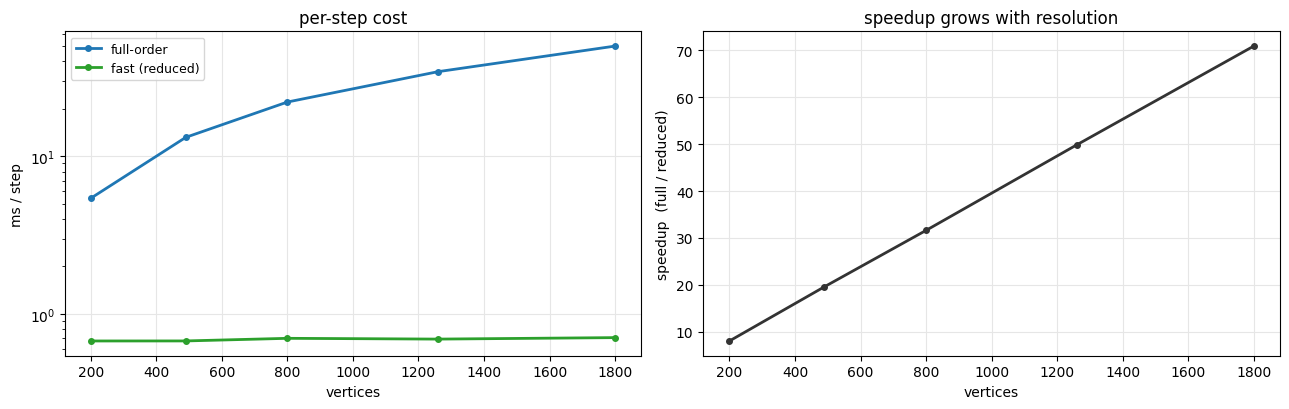

In [20]:
verts, t_fulls, t_reds = [], [], []
for Xs, Ts in sweep_meshes:
    ops_s = cd_operators(Xs, Ts)
    red_ops_s = fast_cd_operators(Xs, Ts, ops_s)
    tf = 1000 * np.median(rollout(full_cd_system, ops_s, BENCH_WARMUP + BENCH_STEPS)["seconds"][BENCH_WARMUP:])
    tr = 1000 * np.median(rollout(fast_cd_system, red_ops_s, BENCH_WARMUP + BENCH_STEPS)["seconds"][BENCH_WARMUP:])
    verts.append(len(Xs))
    t_fulls.append(tf)
    t_reds.append(tr)
    print(f"{len(Xs):5d} verts / {len(Ts):5d} tris:  full {tf:6.1f} ms   reduced {tr:5.2f} ms   ({tf / tr:5.1f}x)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
utils.line_plot(verts, {"full-order": t_fulls, "fast (reduced)": t_reds}, xlabel="vertices", ylabel="ms / step",
                markers=True, logy=True, colors={"full-order": FULL_C, "fast (reduced)": RED_C}, ax=axL,
                title="per-step cost")
utils.line_plot(verts, {"speedup": np.array(t_fulls) / np.array(t_reds)}, xlabel="vertices",
                ylabel="speedup  (full / reduced)", markers=True, colors={"speedup": "0.2"}, ax=axR,
                title="speedup grows with resolution")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "timing.png"),
                              copy_to=os.path.join(MEDIA_DIR, "023_timing.png"))
plt.show()

The full-order cost climbs with the vertex count while the reduced cost stays flat, so the speedup widens with
every refinement.

## Takeaways

* **Complementary dynamics is ordinary elastodynamics plus one constraint**, $J^{\top} M D\,u_c = 0$: the secondary
  motion may carry no momentum the rig accounts for, and the leak field $D$ picks where tissue rides with the rig.
* **Full order enforces it explicitly** with a KKT global step inside ARAP block coordinate descent: correct, but
  both the per-triangle rotations and the KKT solve scale with the mesh.
* **Fast complementary dynamics moves both costs off the mesh**: rig-orthogonal skinning eigenmodes make the
  constraint structural (a tiny unconstrained dense solve), and rotation clustering fixes the number of rotations.
* Apart from the one-line weight-space constraint, every ingredient is a `simkit` call: `lbs_jacobian`,
  `diffuse_field`, `skinning_eigenmodes`, `spectral_cubature`, `cluster_grouping_matrices`, `polar_svd`,
  `solvers.block_coord` and the energies in each `*_system`.